# Project 1: Build Your First AI — Image Classifier**Foundation Arc capstone (Session 7)** • 100 points • Colab GPU required## Goal1. **Part A**: Train a CNN from scratch on CIFAR-10 to ≥70% test accuracy.2. **Part B**: Fine-tune a pre-trained ResNet-18 on a custom 3-class dataset (≥50 images/class).3. **Part C**: Produce loss curves + confusion matrices for both models.4. **Part D**: Write a 1-page reflection on what transfer learning bought you.## Tech stackPyTorch, torchvision, Matplotlib, scikit-learn (confusion matrix).

## SetupEnable the Colab GPU runtime (**Runtime → Change runtime type → T4 GPU**) before running.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Part A — CNN from Scratch on CIFAR-10Load CIFAR-10, build a small CNN, train it, and evaluate. Target ≥70% test accuracy.

In [2]:
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Train size: {len(train_ds)}, Test size: {len(test_ds)}')

100%|██████████| 170M/170M [11:46<00:00, 241kB/s]  


Train size: 50000, Test size: 10000


### Build the CNNA small CNN with 2 conv blocks and 2 fully-connected layers. ~70% on CIFAR-10 is achievable here with proper augmentation.

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Define conv_block1: Conv(3,32,3,pad=1) -> BN -> ReLU -> Conv(32,64,3,pad=1) -> BN -> ReLU -> MaxPool(2)
        self.conv_block1 = None  # TODO

        # TODO: Define conv_block2: Conv(64,128,3,pad=1) -> BN -> ReLU -> Conv(128,128,3,pad=1) -> BN -> ReLU -> MaxPool(2)
        self.conv_block2 = None  # TODO

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # TODO: forward pass — conv_block1 -> conv_block2 -> classifier
        raise NotImplementedError('implement forward pass')

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
print('criterion, optimizer, scheduler ready')

criterion, optimizer, scheduler ready


### Training loop15 epochs is enough to reach ≥70% with this architecture.

In [5]:
train_losses, val_losses, val_accs = [], [], []

for epoch in range(15):
    # TODO: training phase — set train mode, iterate loader, forward/loss/backward/step
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        # TODO: forward pass
        # TODO: compute loss
        # TODO: zero gradients, backward, optimizer.step()
        running_loss += 0.0  # TODO replace with loss.item()
    scheduler.step()

    # TODO: validation phase — set INFERENCE mode, wrap in torch.no_grad(), compute val_loss and val_acc
    val_loss, val_acc = 0.0, 0.0  # TODO compute

    train_losses.append(running_loss / len(train_loader))
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}: train_loss={train_losses[-1]:.3f}, val_loss={val_loss:.3f}, val_acc={val_acc:.2%}')

Epoch 1: train_loss=0.000, val_loss=0.000, val_acc=0.00%


/tmp/ipykernel_3108/3265318319.py:13: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 2: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 3: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 4: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 5: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 6: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 7: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 8: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 9: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 10: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 11: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 12: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 13: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 14: train_loss=0.000, val_loss=0.000, val_acc=0.00%
Epoch 15: train_loss=0.000, val_loss=0.000, val_acc=0.00%


### Loss curves + final accuracy

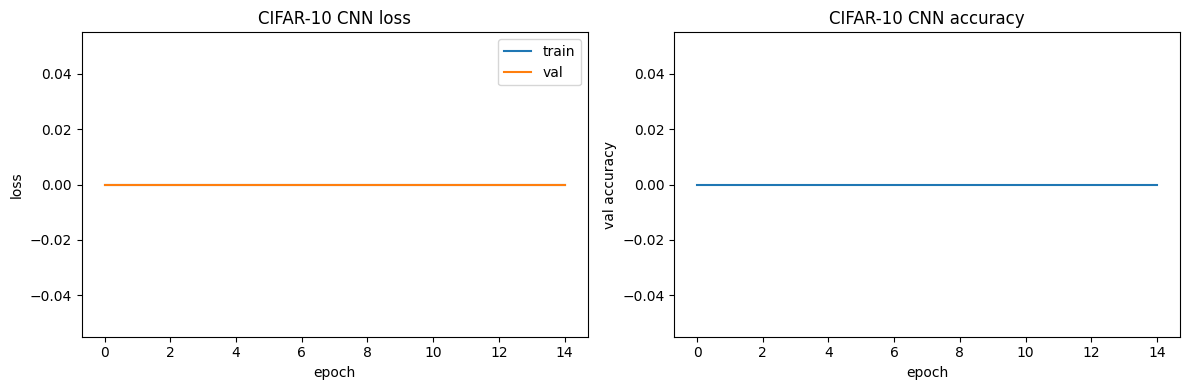

Final test accuracy: 0.00% (target: >=70%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='train')
axes[0].plot(val_losses, label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].set_title('CIFAR-10 CNN loss')
axes[1].plot(val_accs)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val accuracy'); axes[1].set_title('CIFAR-10 CNN accuracy')
plt.tight_layout(); plt.show()

print(f'Final test accuracy: {val_accs[-1]:.2%} (target: >=70%)')

In [8]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation='vertical', cmap='Blues')
plt.title('CIFAR-10 CNN Confusion Matrix'); plt.show()

NotImplementedError: implement forward pass

## Part B — Transfer Learning with ResNet-18Fine-tune a pre-trained ResNet-18 on a custom 3-class dataset. Collect ≥50 images/class.

In [9]:
# Expected folder layout (collect before running):
#   custom_data/
#     class_a/  (50+ images)
#     class_b/  (50+ images)
#     class_c/  (50+ images)
# For demo, we subset CIFAR-10 to 3 classes. Replace with ImageFolder in your submission.

from torch.utils.data import Subset

target_classes = [2, 3, 5]  # bird, cat, dog
remap = {2: 0, 3: 1, 5: 2}
custom_class_names = ['bird', 'cat', 'dog']

def make_subset(dataset, classes):
    indices = [i for i, (_, y) in enumerate(dataset) if y in classes]
    return Subset(dataset, indices)

transform_rn = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
train_rn = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform_rn)
test_rn = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_rn)
custom_train = make_subset(train_rn, target_classes)
custom_test = make_subset(test_rn, target_classes)

custom_train_loader = DataLoader(custom_train, batch_size=64, shuffle=True, num_workers=2)
custom_test_loader = DataLoader(custom_test, batch_size=64, shuffle=False, num_workers=2)
print(f'Custom train: {len(custom_train)}, Custom test: {len(custom_test)}')

Custom train: 15000, Custom test: 3000


In [10]:
from torchvision.models import resnet18, ResNet18_Weights

resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# TODO: freeze all parameters — loop over resnet.parameters() and set requires_grad=False
for param in resnet.parameters():
    param.requires_grad = False
    
# TODO: replace resnet.fc with nn.Linear(resnet.fc.in_features, 3) for 3-class output
resnet.fc = nn.Linear(resnet.fc.in_features, 3)

resnet = resnet.to(device)
print(resnet.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Linear(in_features=512, out_features=3, bias=True)


In [11]:
def map_labels(y): return torch.tensor([remap[int(v)] for v in y])

optimizer_rn = optim.Adam(resnet.fc.parameters(), lr=1e-3)
criterion_rn = nn.CrossEntropyLoss()

rn_train_losses, rn_val_accs = [], []
for epoch in range(5):
    resnet.train()
    running = 0.0
    for images, labels in custom_train_loader:
        labels = map_labels(labels)
        images, labels = images.to(device), labels.to(device)
        optimizer_rn.zero_grad()
        outputs = resnet(images)
        loss = criterion_rn(outputs, labels)
        loss.backward()
        optimizer_rn.step()
        running += loss.item()

    resnet.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in custom_test_loader:
            labels = map_labels(labels).to(device)
            images = images.to(device)
            preds = resnet(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    rn_train_losses.append(running / len(custom_train_loader))
    rn_val_accs.append(correct / total)
    print(f'ResNet epoch {epoch+1}: train_loss={rn_train_losses[-1]:.3f}, val_acc={rn_val_accs[-1]:.2%}')

ResNet epoch 1: train_loss=0.608, val_acc=81.17%
ResNet epoch 2: train_loss=0.457, val_acc=81.57%
ResNet epoch 3: train_loss=0.438, val_acc=81.93%
ResNet epoch 4: train_loss=0.425, val_acc=82.30%
ResNet epoch 5: train_loss=0.417, val_acc=82.33%


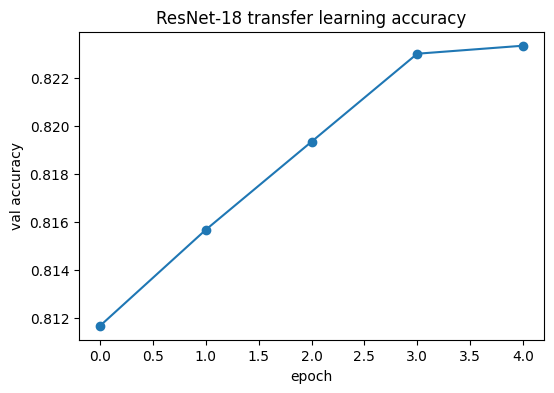

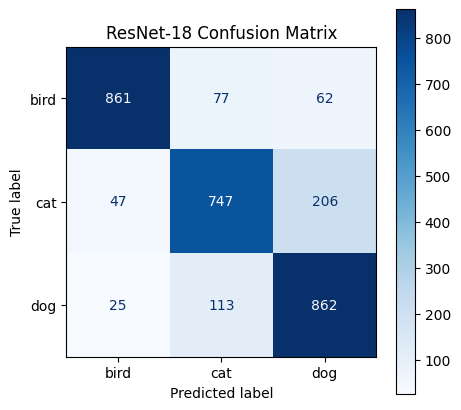

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rn_val_accs, marker='o')
ax.set_xlabel('epoch'); ax.set_ylabel('val accuracy')
ax.set_title('ResNet-18 transfer learning accuracy')
plt.show()

all_preds, all_labels = [], []
resnet.eval()
with torch.no_grad():
    for images, labels in custom_test_loader:
        labels = map_labels(labels).numpy()
        images = images.to(device)
        preds = resnet(images).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=custom_class_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues'); plt.title('ResNet-18 Confusion Matrix'); plt.show()

## Part D — Reflection (1 page)Answer in a markdown cell below:1. **Training time**: from-scratch vs fine-tune. Why is fine-tune faster per-epoch?2. **Accuracy**: which model won and what does that tell you about pre-trained weights?3. **Stuck moment**: describe one >30 min debugging session and how you unstuck yourself.4. **Extension**: if you had another week, what would you try next?Submit via [/learn/ai25/certification](/learn/ai25/certification).

**Your reflection goes here.** Replace this text with your 1-page write-up.